In [1]:
import numpy as np
import matplotlib.pyplot as plt
from vae_definition import VAE
import torch

[Text(0.5, 1.0, 'Loss per iteration'),
 Text(0.5, 0, 'Iteration'),
 Text(0, 0.5, 'Loss [reconstruction + Kullback Liebler div]')]

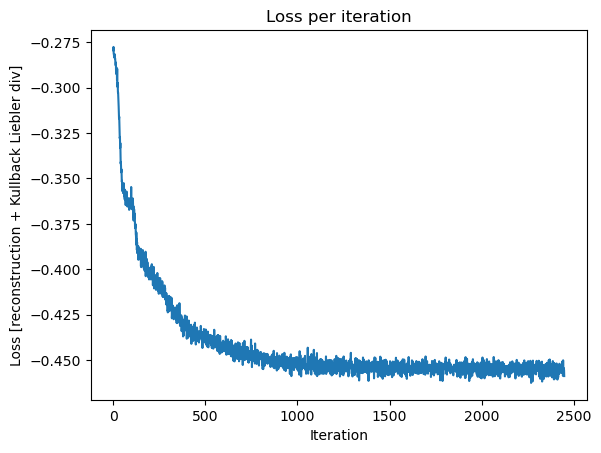

In [4]:
fig, ax = plt.subplots()
losses = np.load("vae_losses.npy")

ax.plot(losses)
ax.set(title="Loss per iteration", xlabel="Iteration", ylabel="Loss [reconstruction + Kullback Liebler div]")

torch.Size([10000, 4])
tensor([[ 1.5540e+00,  2.3310e-08, -6.1745e-01, -2.2641e-04, -3.1380e-01,
         -3.0845e-01],
        [ 1.6194e+00,  2.3443e-08, -3.1739e-01, -1.1668e-04, -3.1546e-01,
         -2.0458e-01],
        [ 1.5004e+00,  2.2821e-08, -7.3745e-01, -3.2624e-04, -3.1634e-01,
         -3.1096e-01],
        ...,
        [ 1.4664e+00,  2.3206e-08, -1.2253e+00, -4.5936e-04, -3.1044e-01,
         -2.7693e-01],
        [ 1.3524e+00,  2.1624e-08, -7.8180e-01, -2.7983e-04, -3.2025e-01,
         -3.8682e-01],
        [ 1.3757e+00,  2.3227e-08, -1.4364e+00, -4.6063e-04, -3.1191e-01,
          4.8091e-02]])


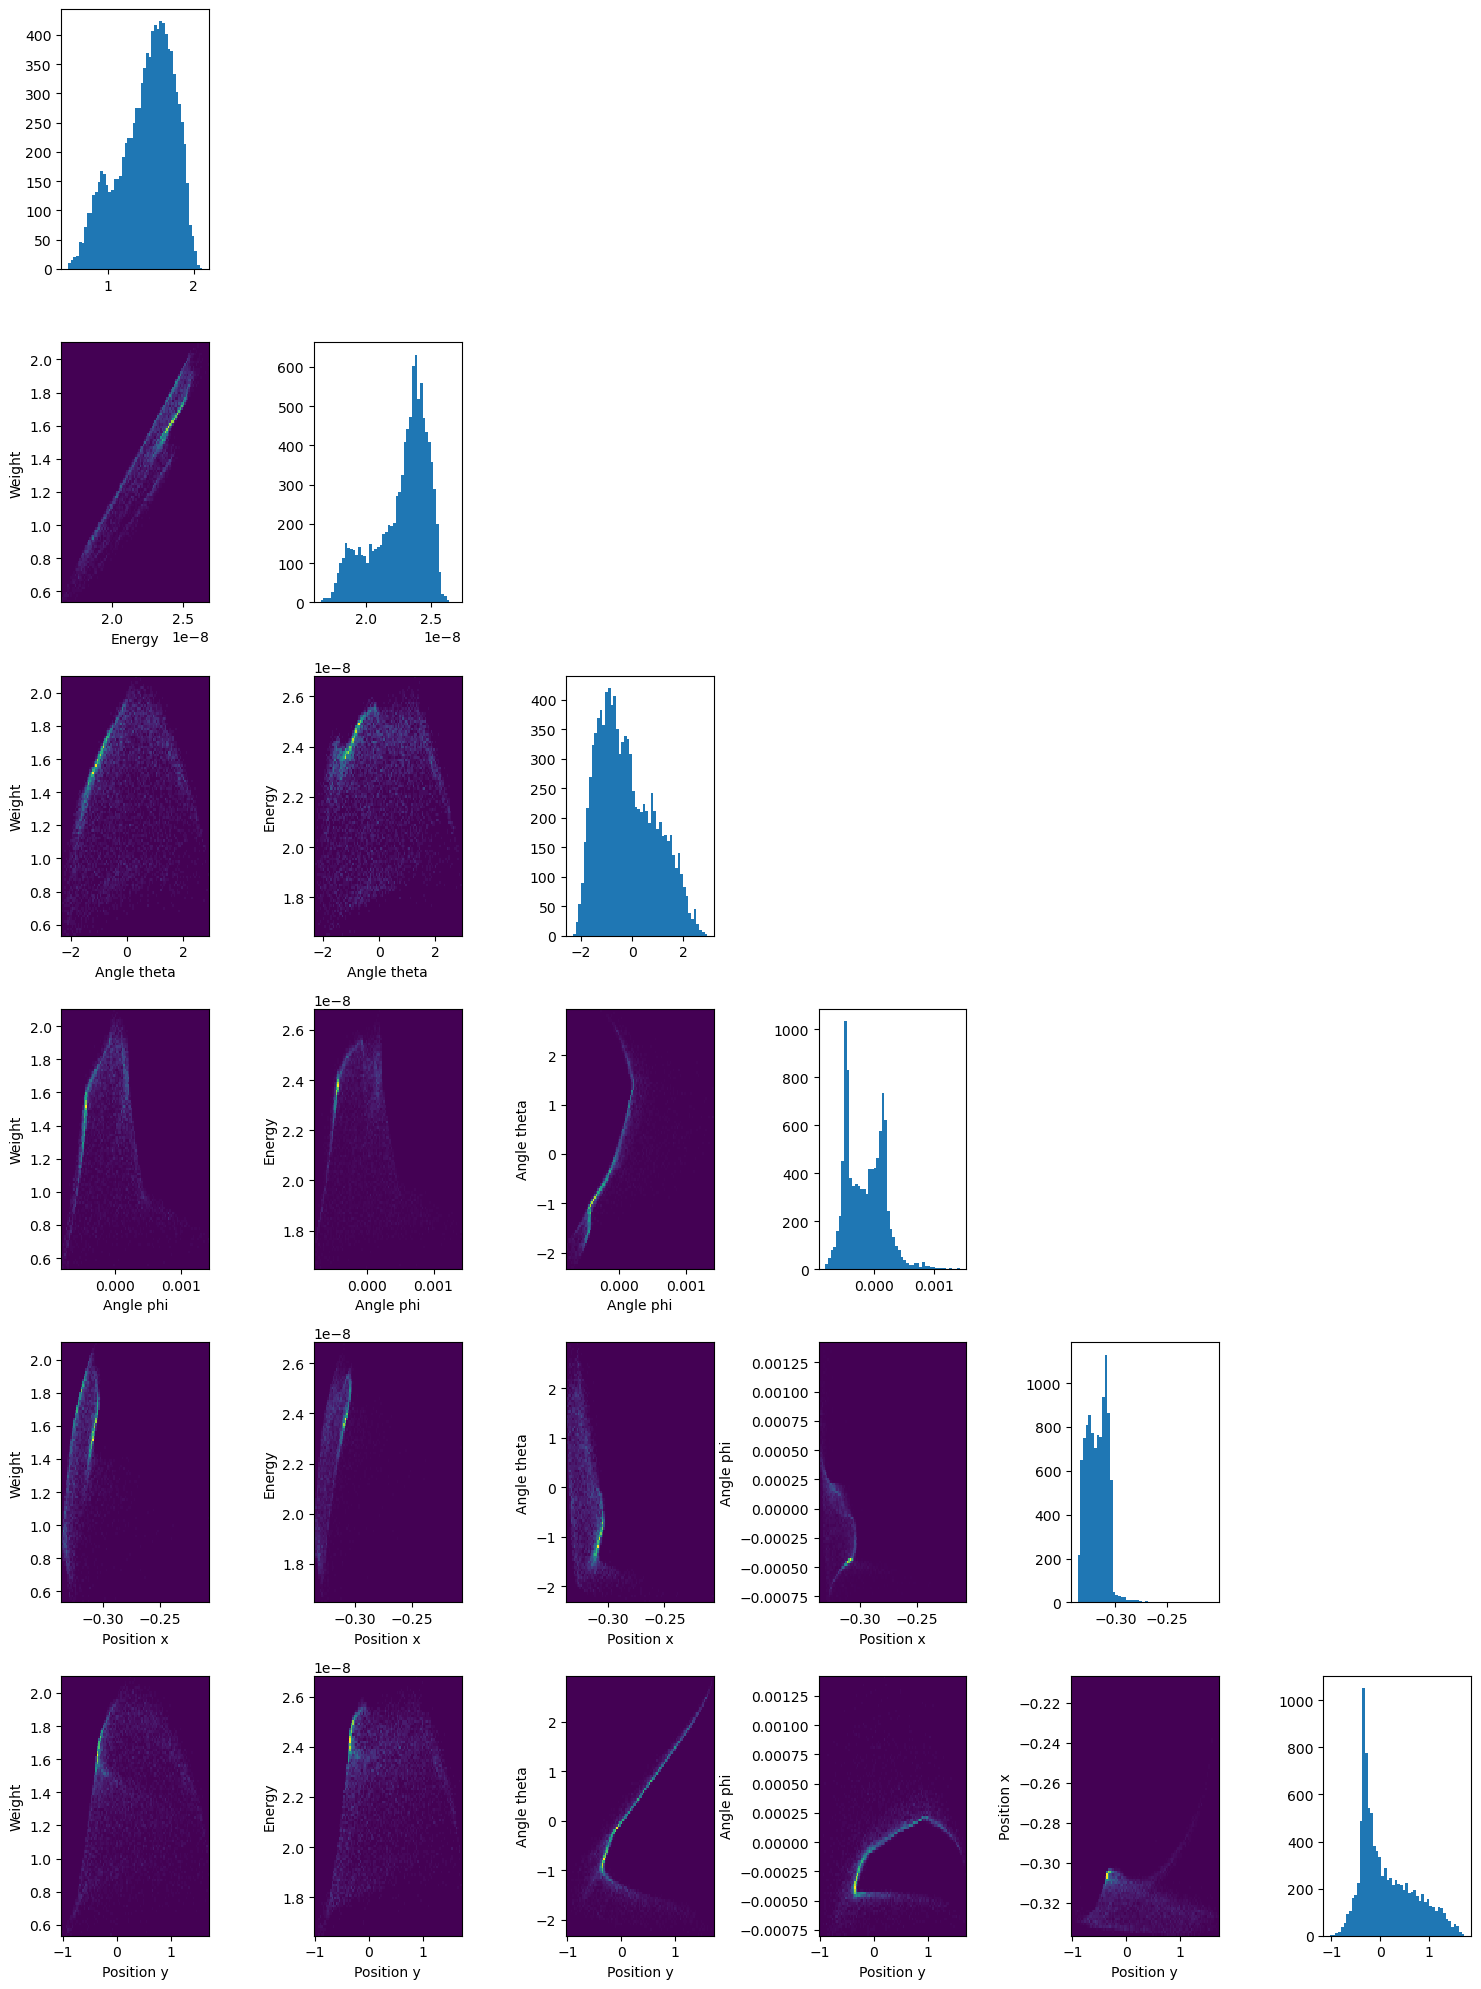

In [3]:
# sample_from_vae.py
device = "mps"

ckpt = torch.load("vae.pth", map_location=device)

vae = VAE().to(device)
vae.load_state_dict(ckpt["state_dict"])
vae.eval()

mins = ckpt["mins"].to(device)       
scales = ckpt["scales"].to(device)  


labels = ["Weight", "Energy", "Angle theta", "Angle phi", "Position x", "Position y"]
with torch.no_grad():
    z = torch.randn(10000,4).to(device)  # sample 1000 latent vectors
    print(z.shape)
    samples = vae.decode(z)              # synthetic data in [0,1]
    samples = samples.clamp(0,1)
    samples = samples * scales + mins
samples = samples.cpu()
print(samples.cpu())
fig, ax = plt.subplots(ncols=6, nrows=6, figsize=(15,20))
for i in range(6):
    for j in range(6):
        if j>i:
            ax[i,j].set_axis_off()
            continue
        if j==i and i!= 7:
            ax[i,j].hist(samples[:,i], bins=50)
            continue
        ax[i,j].hist2d(samples[:,i], samples[:,j], bins=100)
        ax[i,j].set(xlabel=labels[i], ylabel=labels[j])
plt.tight_layout()